# `kNNpy.Auxiliary.PeakStatistics` Tutorial: Peak counts as a cosmological probe

**Author**: kNNpy Tutorials\
**Date**: 3 July 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.Auxiliary.PeakStatistics` module to compute and interpret **peak statistics** — counts of local density maxima above a given threshold — for both Cartesian (flat-sky) and HEALPix (curved-sky) (over)density fields. The basic functionality of the module is illustrated using realistic cosmological datasets shipped with the package. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/Auxiliary/PeakStatistics.html) and the source code for the module are available on the [kNNpy GitHub repository](https://github.com/vikhyat108/kNNpy).

## A brief introduction to peak statistics

Peak statistics are a simple, computationally cheap, and highly informative summary statistic used to characterize the non-Gaussian information imprinted in cosmological (over)density fields, such as weak-lensing convergence maps, galaxy/halo density fields, or the density fields produced directly by $N$-body simulations.

A **peak** is defined as a pixel (or sky position) whose value is greater than or equal to that of all of its immediate neighbours, i.e. a local maximum of the field. Given a density field $\delta(\mathbf{x})$, the **peak function** $n_{\rm pk}(>\nu)$ counts the number of such local maxima whose value exceeds some threshold $\nu$:

$$n_{\rm pk}(>\nu) = \sum_{\mathbf{x}}\ \Theta\big(\delta(\mathbf{x}) - \nu\big)\ \times\ \Theta_{\rm local\,max}(\mathbf{x})$$

Because peaks are associated with the highest-density regions of the field (in projection, these correspond to massive halos and their line-of-sight overdensities), the abundance of peaks as a function of threshold is highly sensitive to the tail of the density PDF and, therefore, to **non-Gaussianities** sourced by non-linear gravitational collapse. This makes peak counts complementary to two-point statistics (like the power spectrum or 2PCF) and, like the $k$-nearest-neighbour (kNN) statistics that form the core of `kNNpy`, sensitive to information encoded in all higher-order connected $N$-point functions of the field.

Peak statistics have been used extensively in the weak-lensing literature to constrain $\Omega_m$, $\sigma_8$, and the properties of dark matter/dark energy, and are a useful cross-check against kNN-CDF-based analyses.

`kNNpy.Auxiliary.PeakStatistics` provides two functions to compute peak curves — i.e., the number of peaks as a function of overdensity threshold — for an ensemble of realizations of one or more cosmological models:

- **`PeakCurves`**: for flat, Cartesian, square (over)density fields (e.g. projected simulation slices, weak-lensing maps in the flat-sky approximation).
- **`PeakCurves_Healpix`**: for full-sky (over)density fields pixelized using the [HEALPix](https://healpix.sourceforge.io/) scheme (e.g. curved-sky weak-lensing or CMB-lensing convergence maps).

Both functions accept an ensemble of realizations for one or more cosmological models, compute the mean peak curve and its standard deviation across realizations, and (optionally) plot the results — either as raw peak counts, or normalized relative to the first input cosmology, which is convenient for highlighting relative differences between models.

<!--TABLE OF CONTENTS-->
# Contents:
- [Imports and Setup](#Imports-and-Setup)
- [Peak Statistics of 2D Cartesian Density Fields](#Peak-Statistics-of-2D-Cartesian-Density-Fields)
    - [Loading and visualizing the data](#Loading-and-visualizing-the-data)
    - [Computing the raw peak curves](#Computing-the-raw-peak-curves)
    - [Computing normalized peak curves](#Computing-normalized-peak-curves)
- [Peak Statistics of HEALPix (Full-Sky) Density Fields](#Peak-Statistics-of-HEALPix-(Full-Sky)-Density-Fields)
    - [Loading and visualizing the data](#Loading-and-visualizing-the-data-(HEALPix))
    - [Computing the raw peak curves](#Computing-the-raw-peak-curves-(HEALPix))
    - [Computing normalized peak curves](#Computing-normalized-peak-curves-(HEALPix))
- [Summary and Tips](#Summary-and-Tips)

# Imports and Setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues. Note that `PeakStatistics.py` additionally requires `healpy`, which is used internally by `PeakCurves_Healpix` to find the neighbours of each HEALPix pixel.

#### A note on plotting: `kNNpy`'s plotting style normally renders text with LaTeX (`usetex=True`). This looks nicer, but requires a working LaTeX installation (e.g. `texlive`) on your system. Below, we auto-detect whether LaTeX is available and fall back to matplotlib's built-in math renderer if it isn't, so this notebook will run either way. If you have LaTeX installed and it isn't being detected, or you'd like to force it on/off, edit the `use_tex` line in the next cell.

In [16]:
#Importing external libraries

import numpy as np
import healpy as hp

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import os
import sys

import warnings
#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy.Auxiliary import PeakStatistics as ps         #the main module

In [17]:
#Matplotlib settings

#kNNpy's plotting style uses LaTeX-rendered text by default. If a working LaTeX installation isn't found on your system,
#we fall back to matplotlib's built-in ('mathtext') renderer so that the notebook still runs (the plots will look
#essentially the same, just without true LaTeX typesetting). If you do have LaTeX installed and want to force it on,
#set 'use_tex = True' manually below.
import shutil
use_tex = shutil.which('latex') is not None

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=use_tex)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Peak Statistics of 2D Cartesian Density Fields

#### First, we demonstrate how to use `PeakCurves` to compare the peak statistics of flat, square (over)density fields drawn from a set of small cosmological simulations.

We will be using five sets of $512\times512$ pixel (over)density field slices, each with 10 independent realizations, generated at high redshift ($z=100$) using the Zel'dovich Approximation (ZA) for different cosmological parameter choices:

- `fZA1_zm100.npy`: the **fiducial** cosmology.
- `Omm1_zm100.npy` / `Omp1_zm100.npy`: the matter density $\Omega_m$ shifted down/up relative to fiducial.
- `s8m1_zm100.npy` / `s8p1_zm100.npy`: the amplitude of matter fluctuations $\sigma_8$ shifted down/up relative to fiducial.

These are the kind of finite-difference simulation pairs typically used to estimate derivatives of a summary statistic with respect to cosmological parameters (see e.g. the [Fisher matrix tutorial](Fisher_tutorial.ipynb) for how such derivatives can be turned into parameter forecasts).

These fields were generated as part of the [**Quijote simulations**](https://quijote-simulations.readthedocs.io/en/latest/) suite. If you use this dataset, please cite Villaescusa-Navarro et al. (2020), *"The Quijote Simulations"*, ApJS, 250, 2 ([arXiv:1909.05273](https://arxiv.org/abs/1909.05273), [DOI:10.3847/1538-4365/ab9d82](https://doi.org/10.3847/1538-4365/ab9d82)).

## Loading and visualizing the data

In [18]:
path = '../kNNpy/Data/PeakStatistics/'

fiducial = np.load(f'{path}fZA1_zm100.npy')
Om_minus = np.load(f'{path}Omm1_zm100.npy')
Om_plus  = np.load(f'{path}Omp1_zm100.npy')
s8_minus = np.load(f'{path}s8m1_zm100.npy')
s8_plus  = np.load(f'{path}s8p1_zm100.npy')

print('Shape of each array (NofRealizations, XdfDim, YdfDim):', fiducial.shape)

Shape of each array (NofRealizations, XdfDim, YdfDim): (10, 512, 512)


Each file contains 10 realizations of a $512\times512$ (over)density field, $\delta = \rho/\bar\rho - 1$. Let's have a look at a single realization of the fiducial field to get a sense of the large-scale structure it contains.

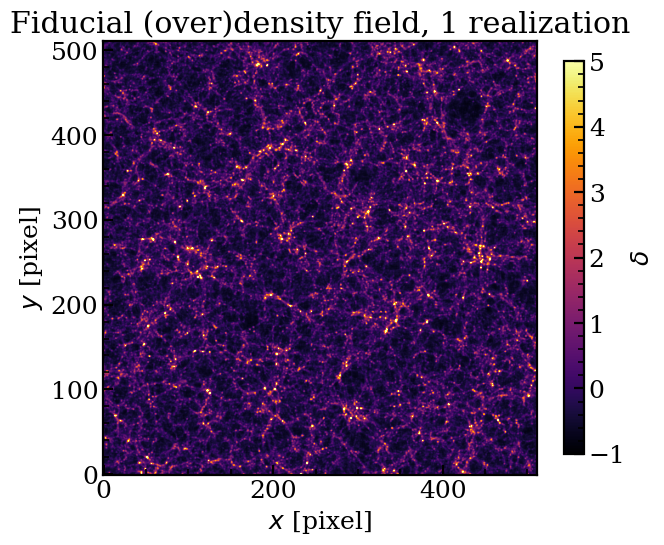

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))
im = ax.imshow(fiducial[0], origin='lower', cmap='inferno', vmin=-1, vmax=5)
ax.set_xlabel('$x$ [pixel]')
ax.set_ylabel('$y$ [pixel]')
ax.set_title('Fiducial (over)density field, 1 realization')
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label(r'$\delta$')
plt.show()

The bright, compact spots correspond to the highest-density regions of the field — these are precisely the local maxima ("peaks") that `PeakCurves` identifies and counts as a function of an overdensity threshold $\nu$.

## Computing the raw peak curves

`PeakCurves` takes a 4D array of shape `(nCosmo, NofRealizations, XdfDim, YdfDim)`, so we stack our five cosmologies together. For each realization, a pixel is flagged as a peak if it is greater than or equal to all of its 8 neighbours (using periodic/wrapped boundary conditions) **and** its value exceeds the current threshold. The threshold is scanned over `Nthresh` values in the closed interval $[-1,$ `MaxThreshold`$]$, and the mean and standard deviation of the peak counts across the `Nreals` realizations are computed and (optionally) plotted, with the shaded band showing the $1\sigma$ scatter across realizations.

20% Done.
40% Done.
60% Done.
80% Done.
100% Done.


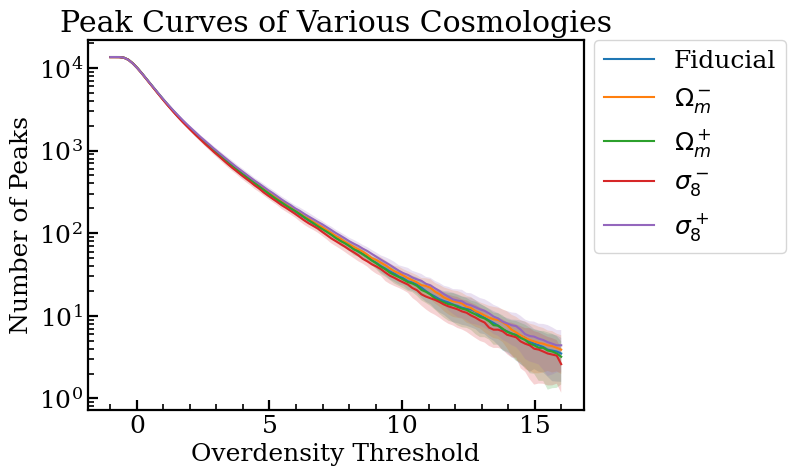

100% Done.


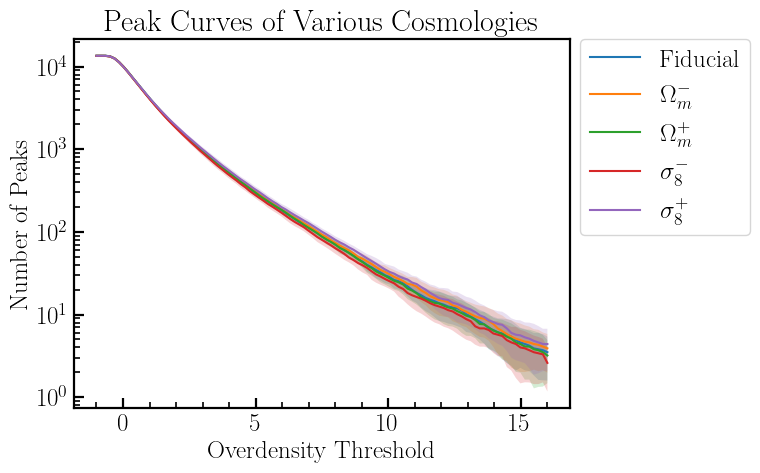

In [20]:
DensityFields = [fiducial, Om_minus, Om_plus, s8_minus, s8_plus]
CosmoLabels = ['Fiducial', r'$\Omega_m^-$', r'$\Omega_m^+$', r'$\sigma_8^-$', r'$\sigma_8^+$']

thresh, tmean, tstddev = ps.PeakCurves(
    DensityFields=DensityFields,
    Nreals=10,
    MaxThreshold=16,
    Nthresh=101,
    Type=0,
    Plot=1,
    LogScale=1,
    CosmoLabels=CosmoLabels
)

As expected, the number of peaks falls off steeply (note the log scale) as the overdensity threshold increases, since high-density peaks are progressively rarer. Models with more matter ($\Omega_m^+$) or more clustering power ($\sigma_8^+$) produce systematically *more* peaks at a given threshold than the fiducial model, while their "minus" counterparts produce *fewer* — exactly the behaviour we would expect from more/less non-linear structure growth.

## Computing normalized peak curves

Because the differences between cosmologies can be subtle on a log-log plot, `PeakCurves` also offers a `Type=1` mode, which normalizes every peak curve by that of the *first* input cosmology (here, the fiducial model). This is often a more sensitive way to visualize how peak statistics respond to changes in cosmological parameters.

20% Done.
40% Done.
60% Done.
80% Done.
100% Done.


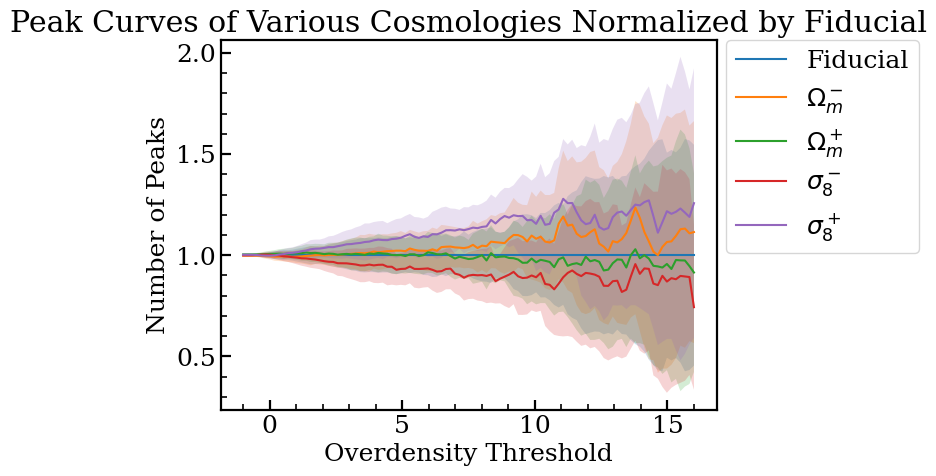

100% Done.


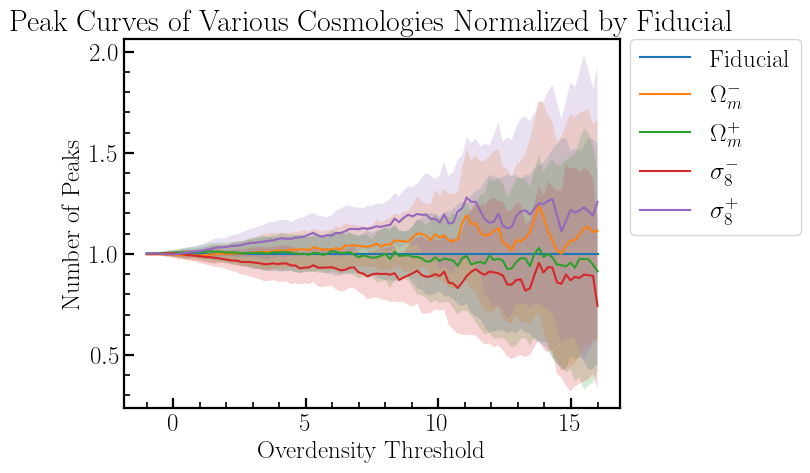

In [21]:
thresh, tmean_norm, tstddev_norm = ps.PeakCurves(
    DensityFields=DensityFields,
    Nreals=10,
    MaxThreshold=16,
    Nthresh=101,
    Type=1,
    Plot=1,
    LogScale=0,
    CosmoLabels=CosmoLabels
)

Normalizing by the fiducial peak curve reveals that the fractional deviations grow with threshold: the most extreme peaks (i.e., the rarest, highest-density regions) are the most sensitive to changes in $\Omega_m$ and $\sigma_8$, which is precisely why peak statistics are such a valuable complement to two-point statistics in cosmological parameter inference — they leverage exactly the non-Gaussian, high-density tail of the field that two-point functions are blind to.

# Peak Statistics of HEALPix (Full-Sky) Density Fields

#### Next, we demonstrate `PeakCurves_Healpix`, the counterpart of `PeakCurves` for full-sky (over)density fields pixelized on a [HEALPix](https://healpix.sourceforge.io/) grid. Instead of using the 8 pixels immediately surrounding each pixel in a Cartesian grid, peaks are identified using the (up to) 8 HEALPix neighbours returned by `healpy.pixelfunc.get_all_neighbours`.

We will compare **Cold Dark Matter (CDM)** against three **Fuzzy Dark Matter (FDM)** models, in which dark matter is composed of an ultra-light boson of mass $m_\phi$. The quantum pressure of a sufficiently light boson suppresses the growth of small-scale structure, which we would expect to show up as a suppression in the abundance of density peaks. We use four sets of full-sky, HEALPix-projected (over)density field slices (`nside=128`, i.e. 196,608 pixels), each with 11 realizations:

- `CDM40_SphericalDensitySlices.npy`: standard Cold Dark Matter.
- `FDM1e22_SphericalDensitySlices.npy`: Fuzzy Dark Matter with $m_\phi = 1\times10^{-22}\,{\rm eV}$ (the lightest, most suppressed case).
- `FDM7e22_SphericalDensitySlices.npy`: Fuzzy Dark Matter with $m_\phi = 7\times10^{-22}\,{\rm eV}$.
- `FDM2e21_SphericalDensitySlices.npy`: Fuzzy Dark Matter with $m_\phi = 2\times10^{-21}\,{\rm eV}$ (the heaviest FDM case here, and thus the closest to CDM).

These HEALPix (over)density field slices were kindly provided by **Prof. Vid Iršič**. If you use this dataset in your own work, please contact Prof. Iršič for the appropriate citation/acknowledgment.

## Loading and visualizing the data (HEALPix)

In [22]:
path = '../kNNpy/Data/PeakStatistics/'

CDM  = np.load(f'{path}CDM40_SphericalDensitySlices.npy')
FDM1 = np.load(f'{path}FDM1e22_SphericalDensitySlices.npy')
FDM2 = np.load(f'{path}FDM2e21_SphericalDensitySlices.npy')
FDM3 = np.load(f'{path}FDM7e22_SphericalDensitySlices.npy')

print('Shape of each array (NofRealizations, nPixels):', CDM.shape)
print('Corresponding HEALPix nside:', hp.npix2nside(CDM.shape[1]))

Shape of each array (NofRealizations, nPixels): (11, 196608)
Corresponding HEALPix nside: 128


Let's visualize a single realization of the CDM field using `healpy`'s Mollweide projection to get a sense of the full-sky (over)density distribution.

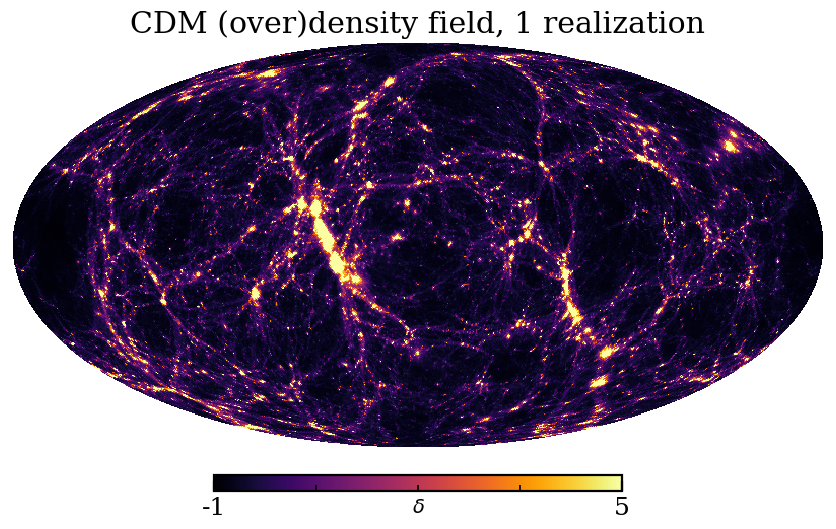

In [23]:
hp.mollview(
    CDM[0],
    title='CDM (over)density field, 1 realization',
    unit=r'$\delta$',
    cmap='inferno',
    min=-1, max=5
)
plt.show()

## Computing the raw peak curves (HEALPix)

`PeakCurves_Healpix` takes a 3D array of shape `(nCosmo, NofRealizations, nPixels)`. Internally, it uses the helper function `spherical_peaks` to identify HEALPix pixels that are greater than or equal to all of their neighbours and exceed a given threshold, following exactly the same logic as `PeakCurves` but adapted for the HEALPix pixelization.

Note that, because `PeakCurves_Healpix` loops in pure Python over thresholds and realizations, it is somewhat slower than its Cartesian counterpart — for the full dataset used below (4 cosmologies $\times$ 11 realizations $\times$ 101 thresholds) it takes on the order of 15-20 seconds to run.

9% Done.
18% Done.
27% Done.
36% Done.
45% Done.
54% Done.
63% Done.
72% Done.
81% Done.
90% Done.
100% Done.


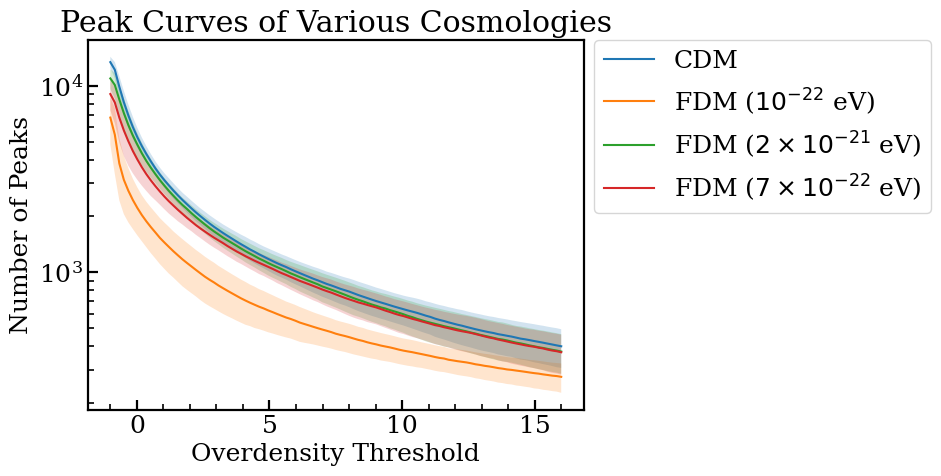

81% Done.


90% Done.


100% Done.


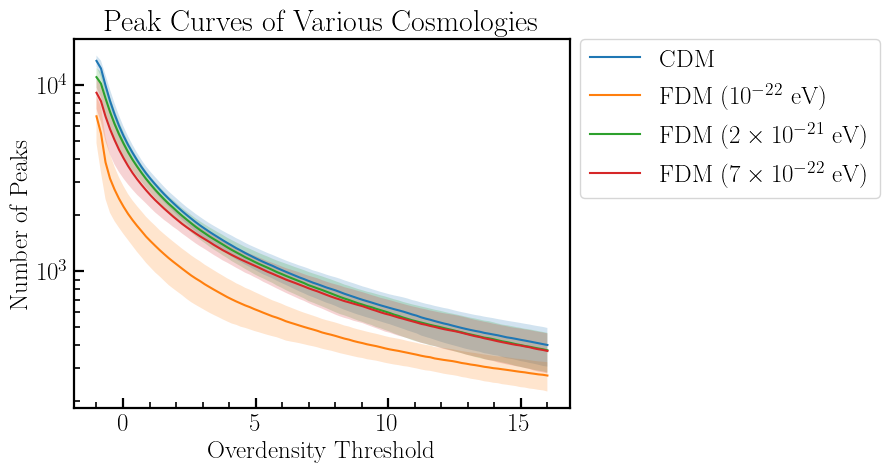

In [27]:
DensityFields_hp = [CDM, FDM1, FDM2, FDM3]
CosmoLabels_hp = ['CDM', r'FDM ($10^{-22}$ eV)', r'FDM ($2\times10^{-21}$ eV)', r'FDM ($7\times10^{-22}$ eV)']

thresh_hp, tmean_hp, tstddev_hp = ps.PeakCurves_Healpix(
    DensityFields=DensityFields_hp,
    Nreals=11,
    MaxThreshold=16,
    Nthresh=101,
    Type=0,
    Plot=1,
    LogScale=1,
    CosmoLabels=CosmoLabels_hp
)

The suppression of small-scale power in Fuzzy Dark Matter shows up clearly as a **deficit of peaks relative to CDM at every threshold**, and the effect is strongest for the lightest boson mass ($10^{-22}$ eV), as expected from the larger quantum-pressure-supported de Broglie wavelength for lighter bosons. The two heavier FDM models sit closer to (but still below) the CDM curve, with the $2\times10^{-21}$ eV model coming closest to CDM overall, since it is the heaviest, least "fuzzy" of the three cases considered.

## Computing normalized peak curves (HEALPix)

As before, we can normalize each model's peak curve by that of the first input cosmology (CDM) to more clearly visualize the fractional suppression as a function of density threshold.

9% Done.
18% Done.
27% Done.
36% Done.
45% Done.
54% Done.
63% Done.
72% Done.
81% Done.
90% Done.
100% Done.


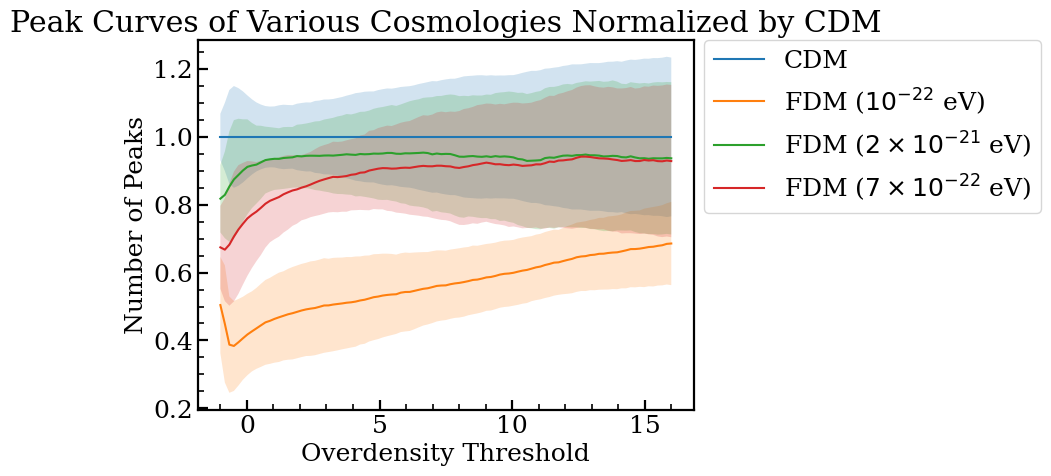

45% Done.


54% Done.


63% Done.


72% Done.


81% Done.


90% Done.


100% Done.


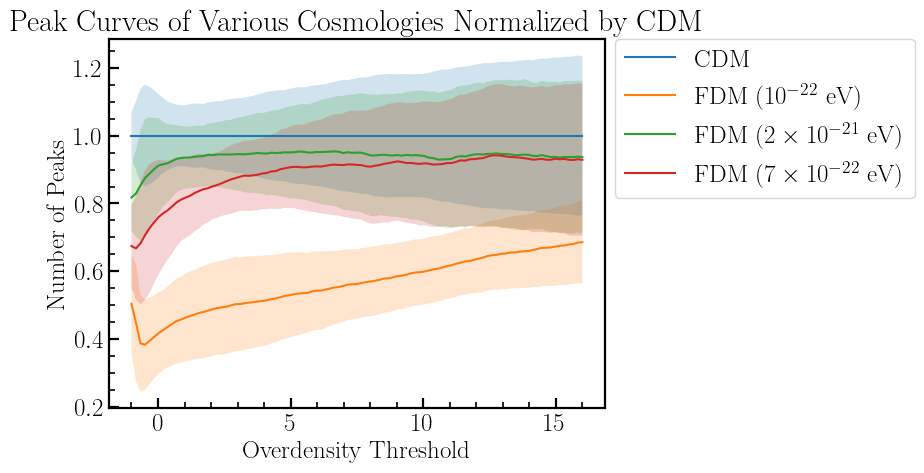

In [25]:
thresh_hp, tmean_hp_norm, tstddev_hp_norm = ps.PeakCurves_Healpix(
    DensityFields=DensityFields_hp,
    Nreals=11,
    MaxThreshold=16,
    Nthresh=101,
    Type=1,
    Plot=1,
    LogScale=0,
    CosmoLabels=CosmoLabels_hp
)

The normalized peak curves highlight that the fractional suppression of peaks relative to CDM is largest at low thresholds for the lightest FDM model, since suppressing small-scale power removes many of the shallow, common peaks that seed later structure formation. This kind of comparison is exactly what makes peak statistics a valuable probe for constraining the properties of dark matter (or any other physics that affects the small-scale, non-linear matter distribution) beyond what is accessible with two-point statistics alone.

# Summary and Tips

In this notebook, we used `kNNpy.Auxiliary.PeakStatistics` to:

- Compute and interpret raw and normalized **peak curves** for flat, Cartesian (over)density fields using `PeakCurves`.
- Compute and interpret raw and normalized peak curves for full-sky, HEALPix-pixelized (over)density fields using `PeakCurves_Healpix`.
- Use peak statistics to distinguish between cosmological models (varying $\Omega_m$ and $\sigma_8$) and between dark matter models (CDM vs. Fuzzy Dark Matter of various particle masses).

A few tips when using these functions on your own data:

- `DensityFields` must be "stackable" into a single array of shape `(nCosmo, NofRealizations, ...)` — i.e., every input cosmology must contain at least `Nreals` realizations of (over)density fields of identical shape.
- `Nreals` cannot exceed the number of realizations actually contained in your input arrays.
- `MaxThreshold` must be greater than $-1$, since $\delta \geq -1$ by definition for an (over)density field.
- If `Plot=1`, `CosmoLabels` must be supplied with exactly one label per input cosmology, in the same order as `DensityFields`.
- Both functions return `(thresh, tmean, tstddev)`, so you can always set `Plot=0` to suppress the built-in plot and instead build your own custom visualization (e.g., to overplot peak curves computed from different datasets, or from theoretical predictions).

## Data Acknowledgments

- The 2D Cartesian (ZA, $z=100$) density fields used in the [first section](#Peak-Statistics-of-2D-Cartesian-Density-Fields) are from the **Quijote simulations**. Please cite Villaescusa-Navarro et al. (2020), *"The Quijote Simulations"*, ApJS, 250, 2 ([arXiv:1909.05273](https://arxiv.org/abs/1909.05273), [DOI:10.3847/1538-4365/ab9d82](https://doi.org/10.3847/1538-4365/ab9d82)) if you use this dataset.
- The HEALPix CDM/FDM density fields used in the [second section](#Peak-Statistics-of-HEALPix-(Full-Sky)-Density-Fields) were kindly provided by **Prof. Vid Iršič**.